In [ ]:
!pip install dotenv pandas seaborn matplotlib scikit-learn xgboost lightgbm catboost

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [ ]:
# Config

LISTINGS_DIR = os.path.join(os.getcwd(), "listings")
print(f"Data directory: {LISTINGS_DIR}")

denver = pd.read_csv(os.path.join(LISTINGS_DIR, "denver_listings.csv"))
denver["location"] = "Denver"

madrid = pd.read_csv(os.path.join(LISTINGS_DIR, "madrid_listings.csv"))
madrid["location"] = "Madrid"

venice = pd.read_csv(os.path.join(LISTINGS_DIR, "venice_listings.csv"))
venice["location"] = "Venice"

zurich = pd.read_csv(os.path.join(LISTINGS_DIR, "zurich_listings.csv"))
zurich["location"] = "Zurich"

Data directory: c:\Users\kuchbhe\Desktop\ml-systems-deep-dive\airbnb-listing-search\experiments\listings


In [4]:
dfs = {
    "denver": denver,
    "madrid": madrid,
    "venice": venice,
    "zurich": zurich,
}

col_sets = {name: set(df.columns) for name, df in dfs.items()}

all_cols = set.union(*col_sets.values())

col_matrix = pd.DataFrame({
    name: [col in cols for col in all_cols]
    for name, cols in col_sets.items()
}, index=sorted(all_cols))

print("Table of column presence across datasets:")
print(col_matrix)

# The columns that are present in all datasets are:
common_cols = set.intersection(*col_sets.values())
print("Total common columns across all datasets:", len(common_cols))


Table of column presence across datasets:
                     denver  madrid  venice  zurich
accommodates           True    True    True    True
amenities              True    True    True    True
availability_30        True    True    True    True
availability_365       True    True    True    True
availability_60        True    True    True    True
...                     ...     ...     ...     ...
review_scores_value    True    True    True    True
reviews_per_month      True    True    True    True
room_type              True    True    True    True
scrape_id              True    True    True    True
source                 True    True    True    True

[80 rows x 4 columns]
Total common columns across all datasets: 80


### Column Alignment Strategy

Upon inspection of the column presence matrix, most core features (e.g., price, room_type, location, availability, and review metrics) are consistently available across all datasets, while several others are location-specific or inconsistently populated.

Using an outer join would introduce significant missing values and additional preprocessing overhead for features that are not central to the analysis.

An inner join is therefore used to retain only the common columns, ensuring:

- a consistent schema
- minimal missing data
- simpler downstream processing

This keeps the dataset focused on the most reliable and comparable features across all locations.

In [5]:
listings = pd.concat(dfs, join="inner", ignore_index=True)
print("Shape of combined dataset:", listings.shape)
print("Columns in combined dataset:", listings.columns.tolist())

listings.head(1)

Shape of combined dataset: (41917, 80)
Columns in combined dataset: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability',

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,location
0,360,https://www.airbnb.com/rooms/360,20250929230429,2025-09-30,city scrape,Denver’s Peaceful Oasis for Travel Nurses & No...,Enjoy the famous Colorado weather and unplug i...,The cottage is located in the center of Lower ...,https://a0.muscache.com/pictures/monet/Select-...,666,...,4.98,4.9,2017-BFN-0002177,f,2,2,0,0,2.14,Denver


## Feature Selection Summary

For this analysis, we restrict the dataset to a **small, high-signal feature set** that captures the core drivers of booking decisions without introducing unnecessary complexity.

---

### Why this subset is sufficient

The selected features directly map to the key components of the system:

- **Utility (price, capacity)** → drives majority preference  
- **Quality (ratings, reviews)** → captures high-value user behavior  
- **Location (lat/long)** → ensures relevance and similarity  

This is enough to simulate:
- ranking behavior  
- majority vs Pareto trade-offs  
- diversity via similarity  

---

### Design choice

Instead of using all available features:
- we avoid noise from irrelevant or redundant columns  
- we keep the system **interpretable and controllable**  
- we ensure experiments isolate **core effects (relevance vs diversity)**  

---

## Final Columns Used

After initial cleaning:
- Removed high-cardinality text columns  
- Dropped columns with high missingness  
- Retained **structured, decision-relevant features**

---

### Core Listing Features (utility)

```python
[
  "price",
  "accommodates",
  "bedrooms",
  "beds",
  "bathrooms",
  "room_type",
  "property_type"
]
```
Meaning

- Defines basic utility of a listing
- Price → strongest driver (majority bias)
- Capacity → functional fit

### Quality Signals

```python
[
  "review_scores_rating",
  "review_scores_cleanliness",
  "review_scores_location",
  "review_scores_value",
  "number_of_reviews",
  "reviews_per_month"
]
```
Meaning

- Proxy for quality + trust
- Important for high-value users
- Enables quality vs price trade-off

### Location
```python
[
  "latitude",
  "longitude",
  "location"
]
```
Meaning

- Core relevance feature
- Used for:
    - distance
    - similarity

---

### Conclusion

This reduced feature set is intentionally minimal:
- captures essential booking dynamics  
- aligns with the experimental goals  
- avoids over-complicating the setup  

For the purpose of validating ranking and diversity mechanisms, **this level of abstraction is sufficient and preferable**.


---

In [6]:
print("\n===== MISSINGNESS =====")
missing = pd.DataFrame({
    "missing_count": listings.isna().sum(),
    "missing_pct": (listings.isna().mean() * 100).round(2)
}).sort_values(by="missing_pct", ascending=False)
print("Top columns by missingness:")
print(missing.head(20))


===== MISSINGNESS =====
Top columns by missingness:
                             missing_count  missing_pct
calendar_updated                     41917       100.00
host_neighbourhood                   25426        60.66
neighborhood_overview                22767        54.31
neighbourhood                        22767        54.31
license                              21438        51.14
host_about                           19782        47.19
host_location                        11758        28.05
price                                 8369        19.97
estimated_revenue_l365d               8369        19.97
bathrooms                             8356        19.93
beds                                  8347        19.91
review_scores_location                7378        17.60
review_scores_value                   7378        17.60
last_review                           7374        17.59
first_review                          7374        17.59
review_scores_cleanliness             7375        1

In [7]:
# Drop columns with >30% missing values

threshold = 0.30

missing_pct = listings.isna().mean()

cols_to_keep = missing_pct[missing_pct <= threshold].index
cols_dropped = missing_pct[missing_pct > threshold].index

listings = listings[cols_to_keep]

print(f"Kept columns: {len(cols_to_keep)}")
print(f"Dropped columns: {len(cols_dropped)}")
print("Dropped columns list:", list(cols_dropped))

Kept columns: 74
Dropped columns: 6
Dropped columns list: ['neighborhood_overview', 'host_about', 'host_neighbourhood', 'neighbourhood', 'calendar_updated', 'license']


In [8]:
# Columns with very low or no variance

low_var_threshold = 1  # <=1 unique value → constant
low_var_cols = listings.nunique()[listings.nunique() <= low_var_threshold].index

print("Low variance columns:", list(low_var_cols))

listings = listings.drop(columns=low_var_cols)

Low variance columns: []


In [9]:
# High cardinality categorical columns

cardinality_threshold = 1000

cat_cols = listings.select_dtypes(include='object')
high_card_cols = cat_cols.nunique()[cat_cols.nunique() > cardinality_threshold].index

print("High cardinality columns:", list(high_card_cols))

listings = listings.drop(columns=high_card_cols)

C:\Users\kuchbhe\AppData\Local\Temp\ipykernel_2892\1103122221.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = listings.select_dtypes(include='object')


High cardinality columns: ['listing_url', 'name', 'description', 'picture_url', 'host_url', 'host_name', 'host_since', 'host_thumbnail_url', 'host_picture_url', 'amenities', 'first_review', 'last_review']


In [90]:
listing_df = listings[[
    "price", "accommodates", "bedrooms", "beds", "bathrooms", "room_type", "property_type",
    "review_scores_rating", "review_scores_cleanliness", "review_scores_location", "review_scores_value", "number_of_reviews", "reviews_per_month",
    "latitude", "longitude", "location"
]]

print(listing_df.shape)
listing_df.head(1)

(41917, 16)


,price,accommodates,bedrooms,beds,bathrooms,room_type,property_type,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,number_of_reviews,reviews_per_month,latitude,longitude,location
0,$139.00,2,2.0,2.0,1.0,Entire home/apt,Entire guesthouse,4.98,4.95,4.98,4.9,186,2.14,39.766415,-105.002098,Denver


In [91]:
# Total missing price percentage
total_missing_price = listing_df['price'].isna().sum()
total_rows = len(listing_df)

pct_missing_price = (total_missing_price / total_rows) * 100
print(f"Overall missing price: {pct_missing_price:.2f}%\n")

# Missing price percentage by location
missing_by_location = listing_df[listing_df['price'].isna()]['location'].value_counts()
total_by_location = listing_df['location'].value_counts()

pct_missing_by_location = (missing_by_location / total_by_location) * 100

print("Percentage of missing price entries by location:\n")
print(pct_missing_by_location.sort_values(ascending=False))

Overall missing price: 19.97%

Percentage of missing price entries by location:

location
Madrid    24.188000
Zurich    24.143986
Denver    12.403259
Venice    10.337602
Name: count, dtype: float64


In [92]:
print("===== LOCATION ANALYSIS FOR MISSING PRICES =====")
print(listing_df[listing_df['price'].isna()]['location'].value_counts())
print(listing_df['location'].value_counts())
print()

# Total missing price percentage
total_missing_price = listing_df['price'].isna().sum()
print(f"Total missing price entries: {total_missing_price}")
print("Total entries:", len(listing_df))

total_rows = len(listing_df)

pct_missing_price = (total_missing_price / total_rows) * 100
print(f"Overall missing price: {pct_missing_price:.2f}%\n")

# Missing price percentage by location
missing_by_location = listing_df[listing_df['price'].isna()]['location'].value_counts()
total_by_location = listing_df['location'].value_counts()

pct_missing_by_location = (missing_by_location / total_by_location) * 100

print("Percentage of missing price entries by location:\n")
print(pct_missing_by_location.sort_values(ascending=False))


print()
print()
print("===== PRICE COLUMN ANALYSIS =====")

# Extract leading currency symbols / patterns
currency_sample = listing_df['price'].dropna().astype(str).str.extract(r'^([^0-9]+)')[0]

# print(currency_sample.value_counts(dropna=False).head(10))
print("Note: The price column contains only $ symbols, no other currency symbols found.")
print("Sample of price values [Before cleaning]:")
print(listing_df['price'].dropna().sample(10, random_state=42).tolist())

listing_df['price_clean'] = (
    listing_df['price']
    .astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)  # remove currency symbols, commas
)

listing_df['price_clean'] = pd.to_numeric(listing_df['price_clean'], errors='coerce')

print("listing_df column cleaned. Sample values [After cleaning]:")
print(listing_df['price_clean'].dropna().sample(10, random_state=42).tolist())

===== LOCATION ANALYSIS FOR MISSING PRICES =====
location
Madrid    6047
Venice     888
Zurich     825
Denver     609
Name: count, dtype: int64
location
Madrid    25000
Venice     8590
Denver     4910
Zurich     3417
Name: count, dtype: int64

Total missing price entries: 8369
Total entries: 41917
Overall missing price: 19.97%

Percentage of missing price entries by location:

location
Madrid    24.188000
Zurich    24.143986
Denver    12.403259
Venice    10.337602
Name: count, dtype: float64


===== PRICE COLUMN ANALYSIS =====
Note: The price column contains only $ symbols, no other currency symbols found.
Sample of price values [Before cleaning]:
['$93.00', '$147.00', '$64.00', '$88.00', '$104.00', '$110.00', '$200.00', '$160.00', '$83.00', '$43.00']
listing_df column cleaned. Sample values [After cleaning]:
[93.0, 147.0, 64.0, 88.0, 104.0, 110.0, 200.0, 160.0, 83.0, 43.0]


In [93]:
listing_df[listing_df['price_clean'].notna()].describe()

,accommodates,bedrooms,beds,bathrooms,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,number_of_reviews,reviews_per_month,latitude,longitude,price_clean
count,33548.000000,33500.000000,33524.000000,33514.000000,28663.000000,28662.000000,28662.000000,28663.000000,33548.000000,28663.000000,33548.000000,33548.000000,33548.000000
mean,3.503130,1.470358,2.083761,1.328266,4.694683,4.728002,4.776927,4.599001,69.872511,2.011502,42.026055,-12.058368,178.825235
std,2.057978,0.956057,1.517872,0.717201,0.430358,0.403033,0.340556,0.457871,117.017400,2.053664,2.649912,36.271344,477.522295
min,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.010000,39.624950,-105.102804,8.000000
25%,2.000000,1.000000,1.000000,1.000000,4.610000,4.660000,4.710000,4.500000,3.000000,0.510000,40.408870,-3.708535,83.000000
50%,3.000000,1.000000,2.000000,1.000000,4.810000,4.840000,4.880000,4.700000,21.000000,1.390000,40.426211,-3.695845,125.000000
75%,4.000000,2.000000,3.000000,1.500000,4.940000,4.960000,4.970000,4.850000,85.000000,2.910000,45.434280,8.547620,185.000000
max,16.000000,25.000000,40.000000,19.000000,5.000000,5.000000,5.000000,5.000000,3315.000000,51.260000,47.427480,12.421180,25654.000000


In [94]:
listing_df[listing_df['price_clean'].isna()].describe()

,accommodates,bedrooms,beds,bathrooms,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,number_of_reviews,reviews_per_month,latitude,longitude,price_clean
count,8369.000000,5425.000000,46.000000,47.0,5880.000000,5880.000000,5877.000000,5876.000000,8369.000000,5880.00000,8369.000000,8369.000000,0.0
mean,2.917672,1.701198,1.195652,1.0,4.655648,4.656082,4.751741,4.571843,28.101446,0.88558,41.591809,-8.160215,NaN
std,1.848152,1.210865,0.453116,0.0,0.556112,0.560386,0.438084,0.593997,72.629625,2.14424,2.473581,27.722401,NaN
min,1.000000,0.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.000000,0.01000,39.626588,-105.095964,NaN
25%,2.000000,1.000000,1.000000,1.0,4.560000,4.560000,4.670000,4.500000,0.000000,0.07000,40.408110,-3.708333,NaN
50%,2.000000,1.000000,1.000000,1.0,4.830000,4.840000,4.900000,4.730000,3.000000,0.29000,40.424850,-3.697880,NaN
75%,4.000000,2.000000,1.000000,1.0,5.000000,5.000000,5.000000,4.930000,21.000000,1.03250,40.462650,-3.636060,NaN
max,16.000000,32.000000,3.000000,1.0,5.000000,5.000000,5.000000,5.000000,1860.000000,82.94000,47.428923,12.417590,NaN


### Handling Missing Values in *price*

Upon examining the missingness in the price column, approximately *20%* of the entries were found to be missing. A closer look at the distribution of these missing values across locations showed some variation—particularly higher in Madrid and Zurich—but not to an extent that suggests a fundamentally different subset of data.

To understand whether imputation was necessary, the distributions of listings with and without price were compared. The differences were minimal, with only slight shifts observed in a few features. This indicates that the missing entries do not represent a distinct or high-signal subgroup, but are more likely lower-quality or incomplete records.

Additionally, the price field serves as a key variable, and introducing imputed values—especially through simplistic methods like median filling—would inject synthetic data and potentially distort downstream analysis.

Given these observations, the decision was made to drop rows with missing price. While this results in a reduction of roughly 20% of the dataset, it ensures a cleaner and more reliable dataset without introducing artificial values, aligning with the goal of maintaining a simple and interpretable preprocessing pipeline.

In [95]:
listing_df = listing_df.dropna(subset=['price_clean'])

print("Remaining missing price:", listing_df['price_clean'].isna().sum())

print("\nPrice summary by location:")
print(listing_df.groupby('location')['price_clean'].describe())

Remaining missing price: 0

Price summary by location:
            count        mean         std   min    25%    50%     75%      max
location                                                                      
Denver     4301.0  163.234829  167.565072   8.0   87.0  123.0  187.00   5000.0
Madrid    18953.0  156.691447  492.255350   8.0   70.0  110.0  164.00  25654.0
Venice     7702.0  241.016100  582.969861  11.0  113.0  158.0  228.00  14264.0
Zurich     2592.0  181.742670  328.257478  10.0   98.0  134.0  198.25  10000.0


In [96]:
print("\n===== MISSINGNESS =====")
missing = pd.DataFrame({
    "missing_count": listing_df.isna().sum(),
    "missing_pct": (listing_df.isna().mean() * 100).round(2)
}).sort_values(by="missing_pct", ascending=False)
print("Top columns by missingness:")
print(missing.head(20))


===== MISSINGNESS =====
Top columns by missingness:
                           missing_count  missing_pct
review_scores_rating                4885        14.56
reviews_per_month                   4885        14.56
review_scores_cleanliness           4886        14.56
review_scores_value                 4885        14.56
review_scores_location              4886        14.56
bedrooms                              48         0.14
bathrooms                             34         0.10
beds                                  24         0.07
price                                  0         0.00
room_type                              0         0.00
property_type                          0         0.00
accommodates                           0         0.00
number_of_reviews                      0         0.00
latitude                               0         0.00
longitude                              0         0.00
location                               0         0.00
price_clean                  

In [97]:
review_cols = [col for col in listing_df.columns if 'review_scores' in col or col == 'reviews_per_month']
for col in review_cols:
    missing_df = listing_df[listing_df[col].isna()]
    
    zero_reviews = (missing_df['number_of_reviews'] == 0).sum()
    total_missing = len(missing_df)
    
    print(f"{col}:")
    print(f"  % with 0 reviews: {(zero_reviews / total_missing) * 100:.2f}%")
    print()

review_scores_rating:
  % with 0 reviews: 100.00%

review_scores_cleanliness:
  % with 0 reviews: 99.98%

review_scores_location:
  % with 0 reviews: 99.98%

review_scores_value:
  % with 0 reviews: 100.00%

reviews_per_month:
  % with 0 reviews: 100.00%



In [98]:
listing_df['has_reviews'] = (listing_df['number_of_reviews'] > 0).astype(int)
listing_df[review_cols] = listing_df[review_cols].fillna(0)

In [99]:
cols = ['bedrooms', 'beds', 'bathrooms']

missing_matrix = listing_df[cols].isna()

print("Rows with any missing:", missing_matrix.any(axis=1).sum())
print("Rows with all three missing:", missing_matrix.all(axis=1).sum())

print("\nOverlap pattern:")
print(missing_matrix.value_counts())

Rows with any missing: 105
Rows with all three missing: 0

Overlap pattern:
bedrooms  beds   bathrooms
False     False  False        33443
True      False  False           47
False     False  True            34
          True   False           23
True      True   False            1
Name: count, dtype: int64


In [100]:
listing_df[~listing_df.isna().any(axis=1)].describe()

,accommodates,bedrooms,beds,bathrooms,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,number_of_reviews,reviews_per_month,latitude,longitude,price_clean,has_reviews
count,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000
mean,3.504799,1.470921,2.081003,1.327453,4.012988,4.041250,4.083055,3.931129,69.948300,1.718239,42.024995,-12.078241,179.052358,0.854738
std,2.051691,0.955947,1.489247,0.711535,1.701434,1.707351,1.712557,1.674927,116.896303,2.019376,2.649001,36.294173,478.202949,0.352370
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.624950,-105.102804,8.000000,0.000000
25%,2.000000,1.000000,1.000000,1.000000,4.400000,4.460000,4.500000,4.260000,3.000000,0.220000,40.408850,-3.708533,83.000000,1.000000
50%,3.000000,1.000000,2.000000,1.000000,4.750000,4.790000,4.840000,4.650000,21.000000,1.030000,40.426211,-3.695833,125.000000,1.000000
75%,4.000000,2.000000,3.000000,1.500000,4.920000,4.940000,4.950000,4.830000,85.000000,2.590000,45.434263,8.547620,185.000000,1.000000
max,16.000000,25.000000,40.000000,19.000000,5.000000,5.000000,5.000000,5.000000,3315.000000,51.260000,47.427480,12.421180,25654.000000,1.000000


In [101]:
listing_df[listing_df.isna().any(axis=1)].describe()

,accommodates,bedrooms,beds,bathrooms,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,number_of_reviews,reviews_per_month,latitude,longitude,price_clean,has_reviews
count,105.000000,57.000000,81.000000,71.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000
mean,2.971429,1.140351,3.222222,1.711268,3.403333,3.451810,3.492000,3.356381,45.733333,1.834476,42.363758,-5.728787,106.485714,0.742857
std,3.506744,0.971718,6.082763,2.059234,2.073647,2.076759,2.109181,2.041803,149.476218,3.664319,2.920093,27.477187,125.462997,0.439155
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.673680,-105.020300,15.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.411950,-3.708600,40.000000,0.000000
50%,2.000000,1.000000,1.000000,1.000000,4.560000,4.630000,4.770000,4.500000,4.000000,0.480000,40.423590,-3.698390,62.000000,1.000000
75%,2.000000,1.000000,2.000000,1.000000,4.860000,4.860000,4.910000,4.810000,29.000000,1.520000,45.444930,8.543650,134.000000,1.000000
max,16.000000,8.000000,30.000000,8.000000,5.000000,5.000000,5.000000,5.000000,1131.000000,22.800000,47.424071,12.362690,1000.000000,1.000000


Since the missigness is random and extremely small, dropped for this experiment.

In [102]:
listing_df = listing_df.dropna(subset=['bedrooms', 'beds', 'bathrooms'])
listing_df.drop(columns=['price'], inplace=True, errors='ignore')

print("Remaining missing:")
print(listing_df[['bedrooms', 'beds', 'bathrooms']].isna().sum())

Remaining missing:
bedrooms     0
beds         0
bathrooms    0
dtype: int64


In [103]:
print("\n===== MISSINGNESS =====")
missing = pd.DataFrame({
    "missing_count": listing_df.isna().sum(),
    "missing_pct": (listing_df.isna().mean() * 100).round(2)
}).sort_values(by="missing_pct", ascending=False)
print("Top columns by missingness:")
print(missing.head(20))


===== MISSINGNESS =====
Top columns by missingness:
                           missing_count  missing_pct
accommodates                           0          0.0
bedrooms                               0          0.0
beds                                   0          0.0
bathrooms                              0          0.0
room_type                              0          0.0
property_type                          0          0.0
review_scores_rating                   0          0.0
review_scores_cleanliness              0          0.0
review_scores_location                 0          0.0
review_scores_value                    0          0.0
number_of_reviews                      0          0.0
reviews_per_month                      0          0.0
latitude                               0          0.0
longitude                              0          0.0
location                               0          0.0
price_clean                            0          0.0
has_reviews                  

---

In [104]:
df_intermediate = listing_df.copy()

In [105]:
binary_cols = ['has_reviews']

num_cols = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'number_of_reviews', 'reviews_per_month', 'price_clean'
]

cat_cols = ['room_type', 'property_type', 'location']

geo_cols = ['latitude', 'longitude']

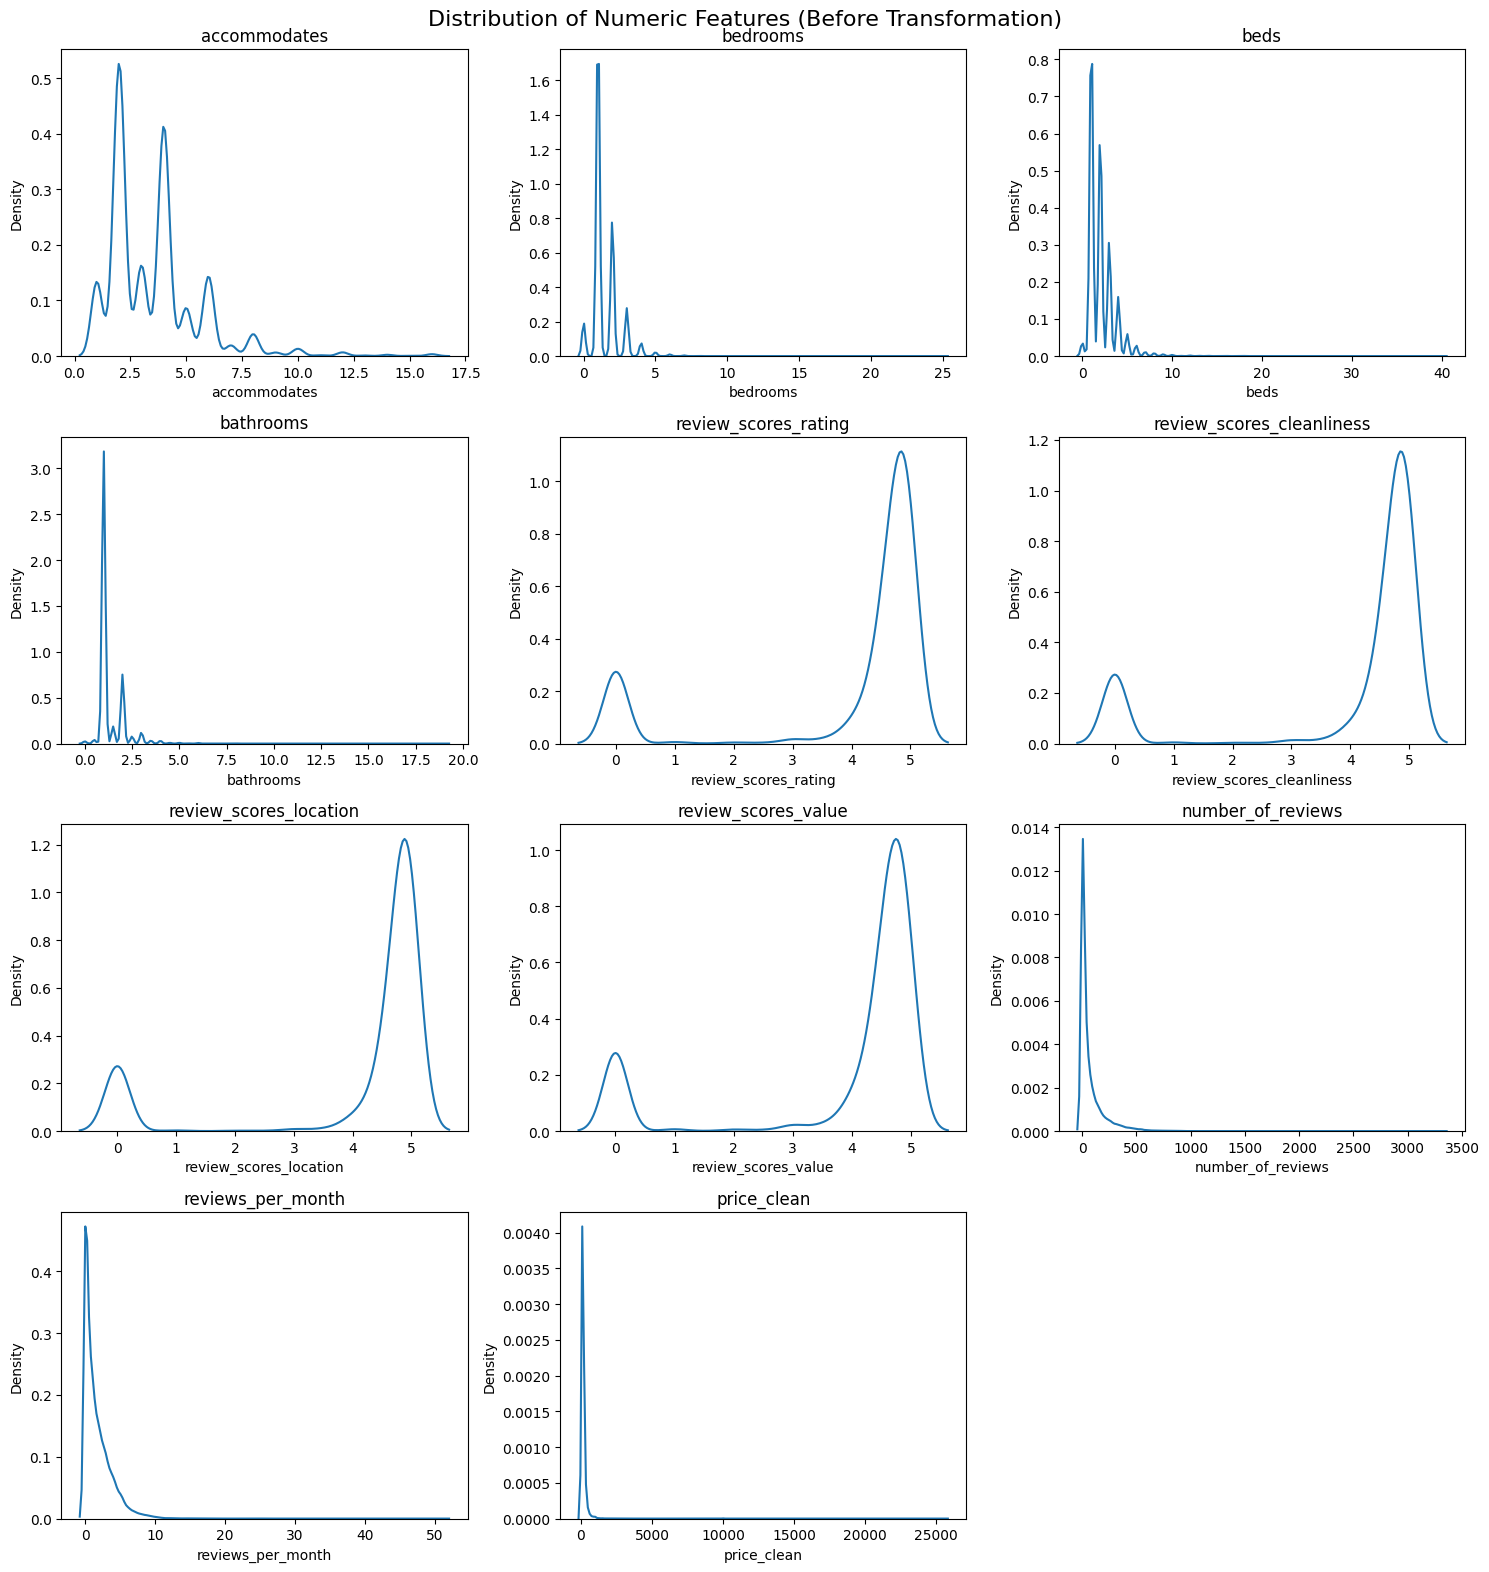

In [64]:
n_cols = 3  # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(df_intermediate[col].dropna(), ax=axes[i])
    axes[i].set_title(col)

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Numeric Features (Before Transformation)", fontsize=16)
plt.tight_layout()
plt.show()

In [66]:
from sklearn.preprocessing import PowerTransformer
cols_to_transform = ['accommodates', 'beds', 'bedrooms', 'bathrooms', 'number_of_reviews', 'reviews_per_month', 'price_clean']
pt = PowerTransformer(method='yeo-johnson')
df_intermediate[cols_to_transform] = pt.fit_transform(df_intermediate[cols_to_transform])

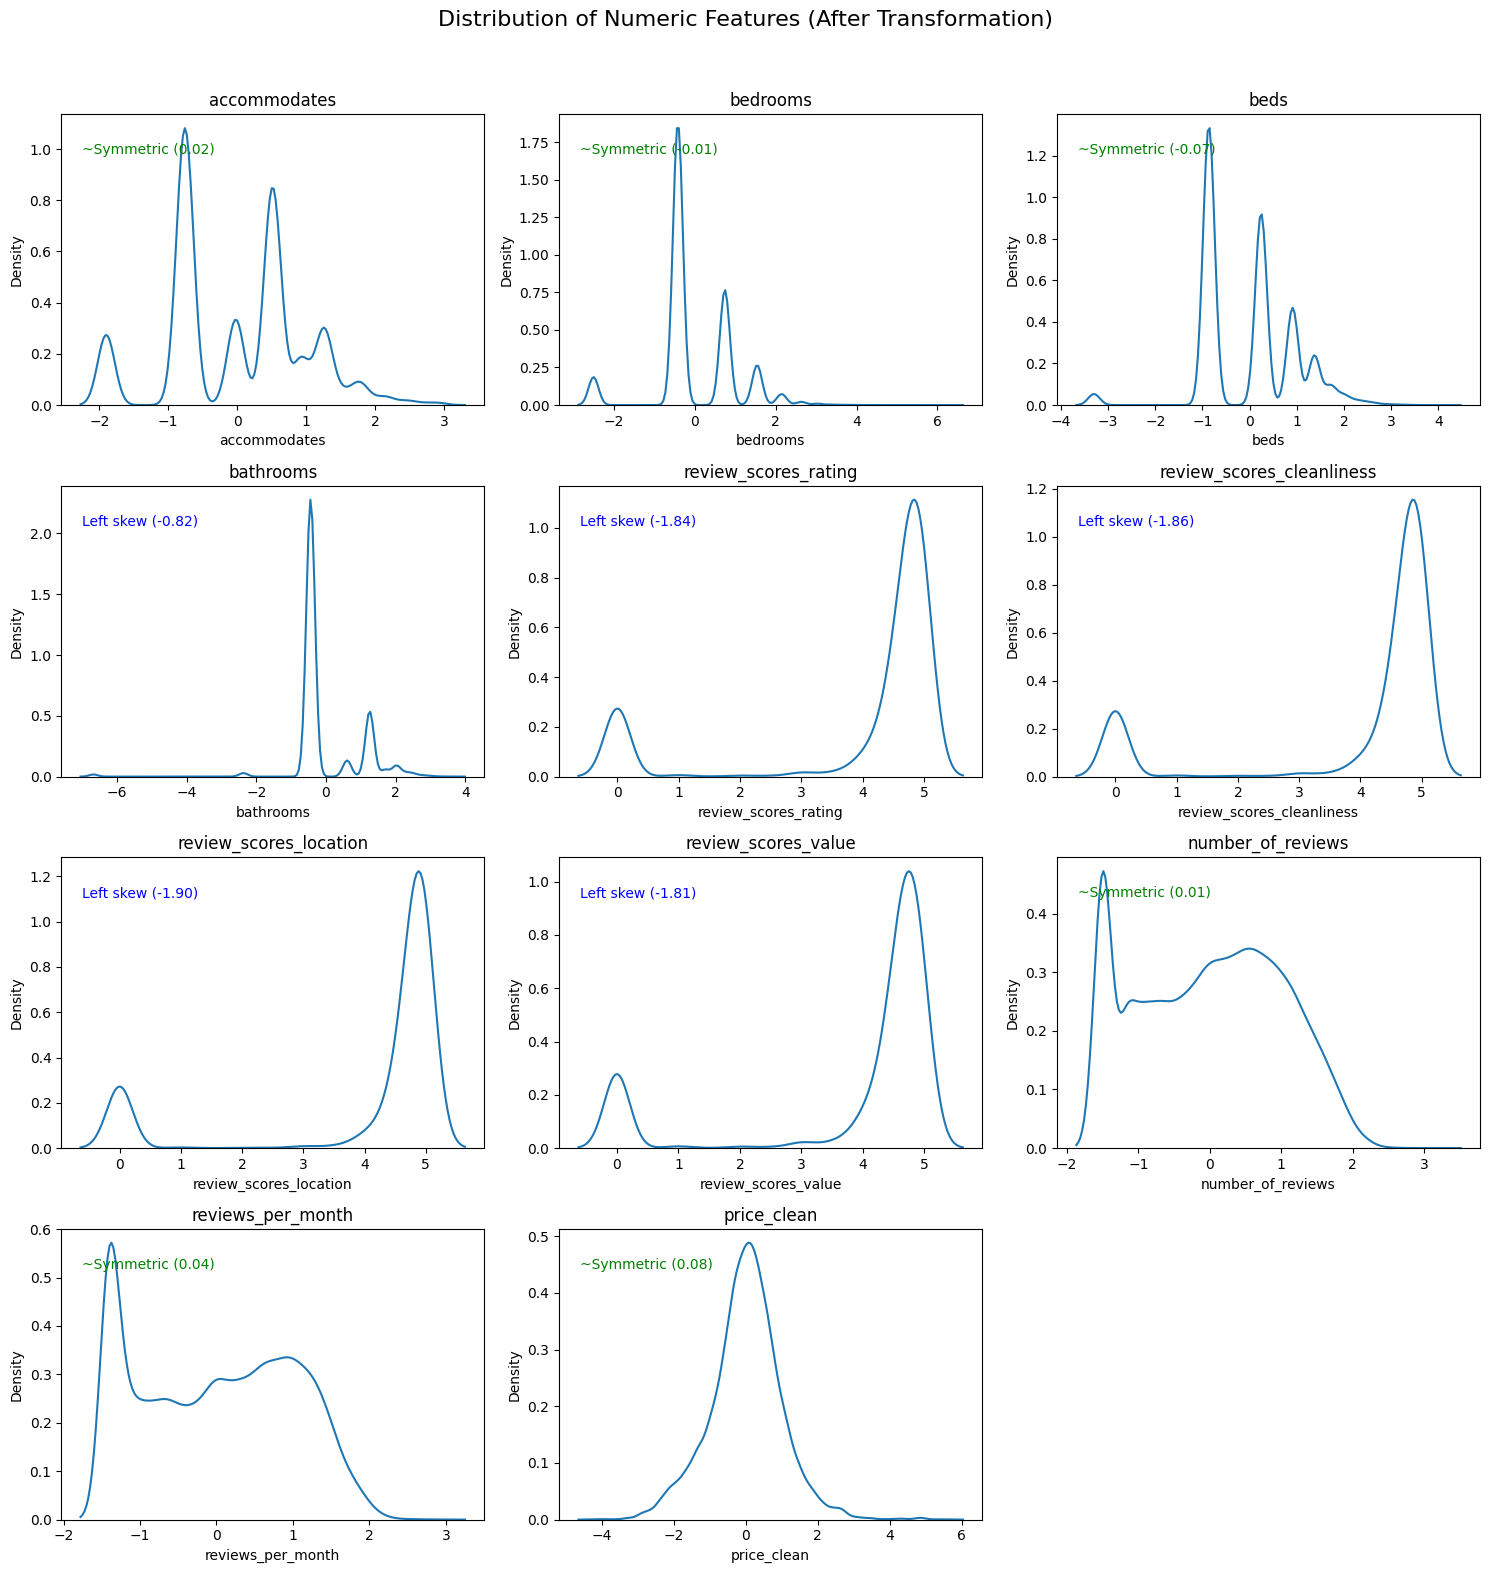

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df_intermediate[col].dropna()
    
    # plot
    sns.kdeplot(data, ax=axes[i])
    
    # compute skew
    skew = data.skew()
    
    # classify
    if skew > 0.5:
        skew_label = f"Right skew ({skew:.2f})"
        color = 'red'
    elif skew < -0.5:
        skew_label = f"Left skew ({skew:.2f})"
        color = 'blue'
    else:
        skew_label = f"~Symmetric ({skew:.2f})"
        color = 'green'
    
    # title + annotation
    axes[i].set_title(col)
    axes[i].text(
        0.05, 0.9,
        skew_label,
        transform=axes[i].transAxes,
        fontsize=10,
        color=color,
        verticalalignment='top'
    )

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Numeric Features (After Transformation)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

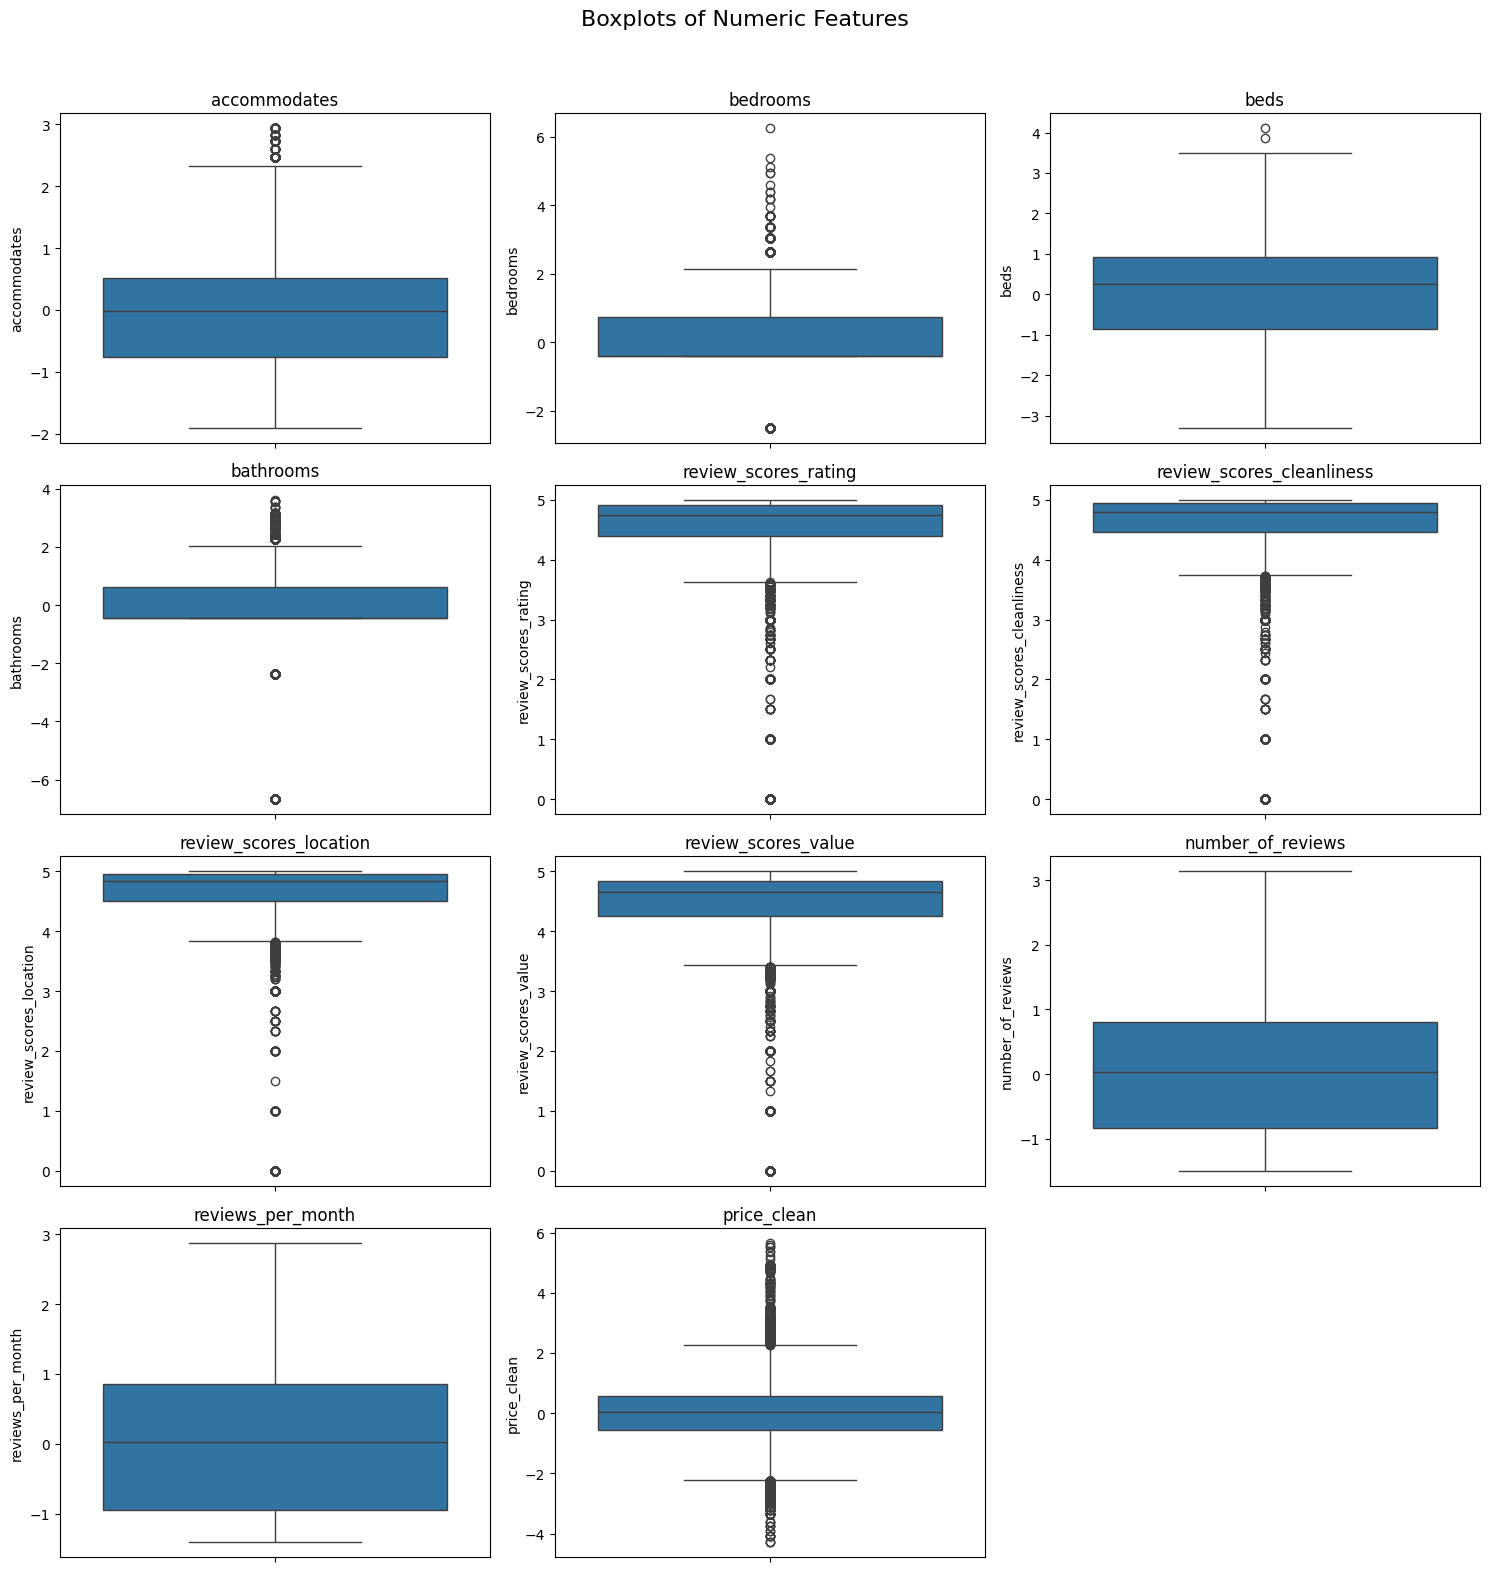

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols_plot = 3
n_rows = math.ceil(len(num_cols) / n_cols_plot)

fig, axes = plt.subplots(n_rows, n_cols_plot, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df_intermediate[col], ax=axes[i])
    axes[i].set_title(col)

# remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots of Numeric Features", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Checking for inconsistencies

In [15]:
df_intermediate.shape

(33443, 17)

In [4]:
df_intermediate.describe(percentiles=[0.25, 0.5, 0.75, 0.85, 0.95, 0.99])

,accommodates,bedrooms,beds,bathrooms,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,number_of_reviews,reviews_per_month,latitude,longitude,price_clean,has_reviews
count,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000
mean,3.504799,1.470921,2.085818,1.327453,4.012988,4.041250,4.083055,3.931129,69.948300,1.718239,42.024995,-12.078241,179.052358,0.854738
std,2.051691,0.955947,1.485489,0.711535,1.701434,1.707351,1.712557,1.674927,116.896303,2.019376,2.649001,36.294173,478.202949,0.352370
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.624950,-105.102804,8.000000,0.000000
25%,2.000000,1.000000,1.000000,1.000000,4.400000,4.460000,4.500000,4.260000,3.000000,0.220000,40.408850,-3.708533,83.000000,1.000000
50%,3.000000,1.000000,2.000000,1.000000,4.750000,4.790000,4.840000,4.650000,21.000000,1.030000,40.426211,-3.695833,125.000000,1.000000
75%,4.000000,2.000000,3.000000,1.500000,4.920000,4.940000,4.950000,4.830000,85.000000,2.590000,45.434263,8.547620,185.000000,1.000000
85%,6.000000,2.000000,3.000000,2.000000,4.990000,5.000000,5.000000,4.900000,149.000000,3.610000,45.443356,12.325558,237.000000,1.000000
95%,7.000000,3.000000,5.000000,2.500000,5.000000,5.000000,5.000000,5.000000,312.000000,5.500000,47.370539,12.341180,396.000000,1.000000
99%,10.000000,5.000000,7.000000,4.000000,5.000000,5.000000,5.000000,5.000000,543.000000,8.705800,47.404389,12.359966,913.160000,1.000000


In [11]:
print("===== OUTLIER ANALYSIS =====")
print("The below table indicates that the outliers don't seem to be data errors but rather very expensive listings (e.g. castles, villas) that are valid but rare.\nWe will keep them in the dataset for modeling, but may consider capping or separate handling if they cause issues.")
print()
df_intermediate[df_intermediate['price_clean'] > 913.160000].sort_values(by='price_clean', ascending=False)

===== OUTLIER ANALYSIS =====
The below table indicates that the outliers don't seem to be data errors but rather very expensive listings (e.g. castles, villas) that are valid but rare.
We will keep them in the dataset for modeling, but may consider capping or separate handling if they cause issues.



,accommodates,bedrooms,beds,bathrooms,room_type,property_type,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,number_of_reviews,reviews_per_month,latitude,longitude,location,price_clean,has_reviews
4714,4,2,3,2.0,Entire home/apt,Entire rental unit,4.90,4.91,4.97,4.85,149,1.19,40.418460,-3.707240,Madrid,25654,1
9061,6,3,0,1.5,Entire home/apt,Entire rental unit,4.00,4.00,4.50,4.00,2,0.04,40.423260,-3.710510,Madrid,23085,1
7055,1,1,2,1.0,Entire home/apt,Entire loft,4.38,4.52,4.84,4.44,117,1.53,40.417356,-3.701313,Madrid,21685,1
8148,5,2,4,1.0,Entire home/apt,Entire rental unit,0.00,0.00,0.00,0.00,0,0.00,40.391400,-3.664250,Madrid,21000,0
13057,4,1,1,1.0,Entire home/apt,Entire rental unit,0.00,0.00,0.00,0.00,0,0.00,40.421349,-3.675481,Madrid,18000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13258,12,4,8,4.0,Entire home/apt,Entire rental unit,5.00,5.00,5.00,4.00,2,0.10,40.432240,-3.707070,Madrid,919,1
8636,4,2,2,2.0,Entire home/apt,Entire rental unit,5.00,5.00,5.00,5.00,4,0.09,40.426440,-3.676560,Madrid,918,1
26552,5,2,3,2.0,Entire home/apt,Entire rental unit,4.82,4.93,4.96,4.69,45,0.89,45.435700,12.334360,Venice,917,1
26802,6,3,4,3.0,Entire home/apt,Entire rental unit,4.96,4.92,5.00,4.56,25,0.52,45.430790,12.329350,Venice,914,1


In [ ]:
print("The below table indicates that the outliers doesn't make any sense. These are likely data errors (e.g. typos) that should be removed or corrected before modeling.")
print()
df_intermediate[df_intermediate['beds'] > 7].sort_values(by='beds', ascending=False)

The below table indicates that the outliers don't seem to be data errors but rather very expensive listings (e.g. castles, villas) that are valid but rare.
We will keep them in the dataset for modeling, but may consider capping or separate handling if they cause issues.



,accommodates,bedrooms,beds,bathrooms,room_type,property_type,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,number_of_reviews,reviews_per_month,latitude,longitude,location,price_clean,has_reviews
19299,16,1,40,2.0,Shared room,Shared room in hotel,4.71,4.64,4.81,4.75,393,51.26,40.404603,-3.694616,Madrid,23,1
20642,10,0,30,7.0,Shared room,Shared room in hotel,4.41,4.57,4.90,4.48,22,4.65,40.419370,-3.709300,Madrid,40,1
13263,1,1,20,8.0,Shared room,Shared room in hotel,4.67,5.00,4.67,5.00,3,0.12,40.387009,-3.646423,Madrid,950,1
20549,2,11,19,19.0,Private room,Private room in home,4.42,4.42,4.88,4.30,33,6.31,40.420838,-3.706688,Madrid,50,1
17665,2,0,19,15.0,Private room,Private room in condo,4.29,4.38,4.89,4.38,73,6.35,40.421999,-3.705869,Madrid,32,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28115,12,6,8,6.0,Entire home/apt,Entire rental unit,4.71,4.88,4.94,4.88,17,0.78,45.446163,12.327319,Venice,855,1
29486,7,3,8,1.0,Entire home/apt,Entire rental unit,4.72,4.28,4.56,4.50,32,3.01,45.486065,12.242186,Venice,64,1
464,10,4,8,3.5,Entire home/apt,Entire home,4.89,4.88,4.84,4.86,273,2.80,39.675050,-104.941620,Denver,193,1
399,14,5,8,3.5,Entire home/apt,Entire home,4.82,4.83,4.75,4.72,142,1.39,39.671450,-104.964860,Denver,272,1


In [19]:
df_intermediate[df_intermediate['bathrooms'] > 5].sort_values(by='bathrooms', ascending=False)

,accommodates,bedrooms,beds,bathrooms,room_type,property_type,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,number_of_reviews,reviews_per_month,latitude,longitude,location,price_clean,has_reviews
519,1,1,1,17.0,Shared room,Shared room in hostel,4.95,4.89,5.00,4.68,19,0.20,39.729690,-104.982880,Denver,52,1
564,1,1,1,17.0,Hotel room,Room in hostel,4.89,4.87,4.86,4.75,277,3.06,39.731160,-104.983070,Denver,50,1
28815,1,17,1,17.0,Private room,Room in hotel,4.75,5.00,4.50,4.00,4,0.97,45.482929,12.255283,Venice,69,1
518,16,1,2,11.0,Shared room,Shared room in hostel,4.74,4.81,4.86,4.72,140,1.49,39.729370,-104.983240,Denver,61,1
27717,16,11,11,11.0,Entire home/apt,Entire vacation home,5.00,5.00,5.00,4.67,3,0.14,45.438462,12.324679,Venice,2886,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20056,2,1,1,5.5,Private room,Private room in rental unit,0.00,0.00,0.00,0.00,0,0.00,40.420973,-3.708249,Madrid,57,0
20243,10,5,5,5.5,Entire home/apt,Entire home,0.00,0.00,0.00,0.00,0,0.00,40.460830,-3.703070,Madrid,600,0
25973,11,6,6,5.5,Entire home/apt,Entire condo,5.00,5.00,5.00,5.00,1,0.26,45.431570,12.326530,Venice,3800,1
27834,10,5,5,5.5,Entire home/apt,Entire home/apt,5.00,5.00,5.00,5.00,1,0.12,45.435209,12.329747,Venice,10350,1


In [26]:
df_intermediate[df_intermediate['bedrooms'] > 5].sort_values(by='bedrooms', ascending=False)

,accommodates,bedrooms,beds,bathrooms,room_type,property_type,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,number_of_reviews,reviews_per_month,latitude,longitude,location,price_clean,has_reviews
8006,16,15,15,4.0,Private room,Private room in hostel,4.41,4.45,4.21,4.17,29,0.55,40.462420,-3.654610,Madrid,100,1
27717,16,11,11,11.0,Entire home/apt,Entire vacation home,5.00,5.00,5.00,4.67,3,0.14,45.438462,12.324679,Venice,2886,1
613,16,10,10,10.5,Hotel room,Room in bed and breakfast,4.92,4.94,4.83,4.71,53,0.61,39.756351,-104.984177,Denver,1272,1
20583,8,8,8,3.0,Private room,Private room in rental unit,0.00,0.00,0.00,0.00,0,0.00,40.425960,-3.682890,Madrid,21,0
18437,16,8,16,6.0,Entire home/apt,Entire rental unit,4.90,5.00,5.00,4.88,51,5.88,40.420280,-3.707980,Madrid,849,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27646,12,6,6,6.5,Entire home/apt,Entire rental unit,5.00,5.00,4.96,4.78,23,0.87,45.441330,12.340400,Venice,1252,1
26842,12,6,8,6.0,Entire home/apt,Entire home,5.00,5.00,5.00,4.83,6,0.18,45.431940,12.332820,Venice,868,1
29359,12,6,6,6.0,Entire home/apt,Entire townhouse,0.00,0.00,0.00,0.00,0,0.00,45.436220,12.334150,Venice,14264,0
30265,12,6,8,6.0,Entire home/apt,Entire home,0.00,0.00,0.00,0.00,0,0.00,45.431320,12.324280,Venice,642,0


In [25]:
# bedrooms cannot exceed accommodates (or at most slightly exceed)
df_intermediate = df_intermediate[df_intermediate['bedrooms'] <= df_intermediate['accommodates']+1]
df_intermediate.shape

(33262, 17)

In [16]:
# Remove listings where beds > accommodates * 2 (e.g. 10 beds for 2 guests) as these are likely data errors (listings for the entire building or shared dorms)
df_intermediate = df_intermediate[~(
    (df_intermediate['beds'] > df_intermediate['accommodates'] * 2)
)]

df_intermediate.shape

(33311, 17)

In [107]:
df_intermediate[
    (df_intermediate['number_of_reviews'] == 0) & ((df_intermediate[['review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value']] > 0).any(axis=1))
].shape

(0, 17)

In [108]:
subset_0bed = df_intermediate[
    (df_intermediate[['beds', 'bedrooms']] == 0).all(axis=1)
]

subset_0bed.shape

(93, 17)

In [109]:
subset_0bed[['room_type', 'property_type']].value_counts()

room_type        property_type              
Entire home/apt  Entire rental unit             56
                 Room in aparthotel             20
                 Entire serviced apartment       4
                 Entire condo                    3
Private room     Private room in rental unit     2
Entire home/apt  Entire loft                     2
Private room     Room in hotel                   2
Entire home/apt  Entire guesthouse               1
                 Entire guest suite              1
Private room     Private room in guesthouse      1
Shared room      Shared room in rental unit      1
Name: count, dtype: int64

In [118]:
import numpy as np

mask = (
    (df_intermediate['beds'] == 0) &
    (df_intermediate['bedrooms'] == 0) 
)

df_intermediate.loc[mask, 'beds'] = np.nan

In [119]:
df_intermediate['beds'] = df_intermediate.groupby(
    ['room_type', 'property_type']
)['beds'].transform(lambda x: x.fillna(x.median()))

df_intermediate['beds'] = df_intermediate['beds'].fillna(df_intermediate['beds'].median())

In [121]:
mask = (
    (df_intermediate['beds'] == 0) &
    (df_intermediate['bedrooms'] == 0)
)

df_intermediate[mask].shape

(0, 17)

In [136]:
df_intermediate[
    df_intermediate['beds'] > df_intermediate['accommodates'] * 3
][['beds', 'accommodates']].head()

,beds,accommodates
780,10.0,1
2435,4.0,1
3768,4.0,1
3852,9.0,2
4164,10.0,1


In [139]:
df_intermediate.info()

<class 'pandas.DataFrame'>
Index: 33443 entries, 0 to 41916
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   accommodates               33443 non-null  int64  
 1   bedrooms                   33443 non-null  int64  
 2   beds                       33443 non-null  int64  
 3   bathrooms                  33443 non-null  float64
 4   room_type                  33443 non-null  str    
 5   property_type              33443 non-null  str    
 6   review_scores_rating       33443 non-null  float64
 7   review_scores_cleanliness  33443 non-null  float64
 8   review_scores_location     33443 non-null  float64
 9   review_scores_value        33443 non-null  float64
 10  number_of_reviews          33443 non-null  int64  
 11  reviews_per_month          33443 non-null  float64
 12  latitude                   33443 non-null  float64
 13  longitude                  33443 non-null  float64
 14  locati

In [138]:
def convert_valid_int_cols(df, tol=1e-9, verbose=True):
    df = df.copy()
    
    for col in df.columns:
        if df[col].dtype == 'float64':
            values = df[col].dropna()
            
            if np.all(np.abs(values - np.round(values)) < tol):
                if verbose:
                    print(f"Converting {col} → int")
                df[col] = df[col].round().astype(int)
    
    return df

df_intermediate = convert_valid_int_cols(df_intermediate)

Converting bedrooms → int
Converting beds → int
Converting price_clean → int


#### Finished EDA, VIsualization and Cleaning

---

In [2]:
DATA_DIR = os.path.join(os.getcwd(), "data")
df_intermediate = pd.read_csv(os.path.join(DATA_DIR, "clean_listings.csv"))

In [3]:
df_intermediate.describe(percentiles=[0.25, 0.5, 0.75, 0.85, 0.95, 0.99])

,accommodates,bedrooms,beds,bathrooms,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,number_of_reviews,reviews_per_month,latitude,longitude,price_clean,has_reviews
count,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000,33443.000000
mean,3.504799,1.470921,2.085818,1.327453,4.012988,4.041250,4.083055,3.931129,69.948300,1.718239,42.024995,-12.078241,179.052358,0.854738
std,2.051691,0.955947,1.485489,0.711535,1.701434,1.707351,1.712557,1.674927,116.896303,2.019376,2.649001,36.294173,478.202949,0.352370
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.624950,-105.102804,8.000000,0.000000
25%,2.000000,1.000000,1.000000,1.000000,4.400000,4.460000,4.500000,4.260000,3.000000,0.220000,40.408850,-3.708533,83.000000,1.000000
50%,3.000000,1.000000,2.000000,1.000000,4.750000,4.790000,4.840000,4.650000,21.000000,1.030000,40.426211,-3.695833,125.000000,1.000000
75%,4.000000,2.000000,3.000000,1.500000,4.920000,4.940000,4.950000,4.830000,85.000000,2.590000,45.434263,8.547620,185.000000,1.000000
85%,6.000000,2.000000,3.000000,2.000000,4.990000,5.000000,5.000000,4.900000,149.000000,3.610000,45.443356,12.325558,237.000000,1.000000
95%,7.000000,3.000000,5.000000,2.500000,5.000000,5.000000,5.000000,5.000000,312.000000,5.500000,47.370539,12.341180,396.000000,1.000000
99%,10.000000,5.000000,7.000000,4.000000,5.000000,5.000000,5.000000,5.000000,543.000000,8.705800,47.404389,12.359966,913.160000,1.000000


In [ ]:
FEATURE_COLS = [
    "price_clean",
    "review_scores_rating",
    "review_scores_cleanliness"
    "review_scores_location",
    "review_scores_value",
    "number_of_reviews",
    "bedrooms",
    "bathrooms",
    "reviews_per_month",
    "has_reviews"
]

import numpy as np

def normalize(df, cols):
    X = df[cols].values.astype(float)
    mean = X.mean(axis=0)
    std = X.std(axis=0) + 1e-8
    return (X - mean) / std, mean, std


def sample_user_weights():
    if np.random.rand() < 0.8:
        # Majority (price sensitive)
        return np.array([
            -1.2,  # price
             0.5,  # rating
             0.2,  # cleanliness
             0.2,  # location
             0.4,  # value
             0.3,  # reviews
             0.2,  # bedrooms
             0.2,  # bathrooms
             0.1,  # reviews_per_month
             0.2   # has_reviews
        ])
    else:
        # Minority (quality seeking)
        return np.array([
            -0.3,
             1.2,
             0.5,
             0.5,   
             0.2,
             0.8,
             0.4,
             0.4,
             0.3,
             0.3
        ])
    

def softmax(x):
    x = x - np.max(x)  # stability
    exp_x = np.exp(x)
    return exp_x / exp_x.sum()

def cosine_sim(a, b):
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

def simulate_choice(X, w, sigma=0.3):
    noise = np.random.normal(0, sigma, size=X.shape[0])
    utility = X @ w + noise
    probs = softmax(utility)
    
    chosen_idx = np.random.choice(len(probs), p=probs)
    return chosen_idx, probs

def simulate_choice_with_diversity(X, w, lambda_=0.5, sigma=0.3):
    noise = np.random.normal(0, sigma, size=X.shape[0])
    
    base_utility = X @ w
    
    penalty = np.zeros(len(X))
    for i in range(len(X)):
        for j in range(len(X)):
            if i != j:
                penalty[i] += cosine_sim(X[i], X[j])
    
    utility = base_utility - lambda_ * penalty + noise
    
    probs = softmax(utility)
    chosen_idx = np.random.choice(len(probs), p=probs)
    
    return chosen_idx, probs

def simulate_query(df, X_norm, k=30):
    idx = np.random.choice(len(df), size=k, replace=False)
    
    X = X_norm[idx]
    w = sample_user_weights()
    
    chosen_idx, probs = simulate_choice_with_diversity(X, w)
    
    booked = idx[chosen_idx]
    not_booked = np.delete(idx, chosen_idx)
    
    return booked, not_booked, idx, probs

def generate_pairs(df, n_queries=5000, k=30):
    X_norm, _, _ = normalize(df, FEATURE_COLS)
    
    pairs = []
    
    for _ in range(n_queries):
        booked, not_booked, _, _ = simulate_query(df, X_norm, k)
        
        for neg in not_booked:
            pairs.append((booked, neg))
    
    return pairs

def generate_labeled(df, n_queries=5000, k=30):
    X_norm, _, _ = normalize(df, FEATURE_COLS)
    
    rows = []
    
    for qid in range(n_queries):
        idx = np.random.choice(len(df), size=k, replace=False)
        X = X_norm[idx]
        w = sample_user_weights()
        
        chosen_idx, probs = simulate_choice_with_diversity(X, w)
        
        for i, listing_idx in enumerate(idx):
            rows.append({
                "query_id": qid,
                "listing_id": listing_idx,
                "booked": int(i == chosen_idx),
                "prob": probs[i]
            })
    
    return rows

df_pairs = generate_labeled(df_intermediate)

In [142]:
df_pairs

[{'query_id': 0,
  'listing_id': np.int32(24244),
  'booked': 0,
  'prob': np.float64(0.0005388405046759424)},
 {'query_id': 0,
  'listing_id': np.int32(29677),
  'booked': 0,
  'prob': np.float64(0.001196203291953)},
 {'query_id': 0,
  'listing_id': np.int32(3506),
  'booked': 0,
  'prob': np.float64(0.001755704518982639)},
 {'query_id': 0,
  'listing_id': np.int32(21897),
  'booked': 0,
  'prob': np.float64(0.0038719373879991365)},
 {'query_id': 0,
  'listing_id': np.int32(23412),
  'booked': 1,
  'prob': np.float64(0.9091953114176639)},
 {'query_id': 0,
  'listing_id': np.int32(22392),
  'booked': 0,
  'prob': np.float64(0.0011948528517771154)},
 {'query_id': 0,
  'listing_id': np.int32(5781),
  'booked': 0,
  'prob': np.float64(0.001649754003139214)},
 {'query_id': 0,
  'listing_id': np.int32(23513),
  'booked': 0,
  'prob': np.float64(0.0013529351349856134)},
 {'query_id': 0,
  'listing_id': np.int32(11806),
  'booked': 0,
  'prob': np.float64(0.0004779049676853453)},
 {'query_id'

In [144]:
simulate_query(df_intermediate, normalize(df_intermediate, FEATURE_COLS)[0], k=30)

(np.int32(19342),
 array([21729, 33222, 25550, 18297, 16495, 11781, 24645, 21449,  9905,
        17065, 31496, 26325, 21913,  2186, 25291,  1944, 12961, 24844,
         8895, 23513,  4765, 26545, 26892, 29153,  3617,   270,  2693,
         7698, 13889], dtype=int32),
 array([21729, 33222, 25550, 18297, 16495, 11781, 24645, 21449,  9905,
        17065, 31496, 26325, 21913,  2186, 25291,  1944, 12961, 24844,
         8895, 23513,  4765, 26545, 26892, 29153,  3617,   270,  2693,
        19342,  7698, 13889], dtype=int32),
 array([0.16458796, 0.00407584, 0.09571363, 0.02180575, 0.00311133,
        0.00058312, 0.00107649, 0.01971955, 0.01828477, 0.02000314,
        0.00070536, 0.01129218, 0.22243655, 0.09287774, 0.09452135,
        0.00102777, 0.02096682, 0.06179288, 0.01362484, 0.00156651,
        0.00144448, 0.00437132, 0.00242754, 0.02658503, 0.01221132,
        0.01755463, 0.00184894, 0.05484769, 0.0017631 , 0.00717237]))